# Vanguard A/B Test Analysis

In this project, I analyze whether Vanguard's new digital experience improved the user journey compared with the Control group.

I wanted the notebook to answer three things:
- Did the new design improve completion?
- Did it reach Vanguard's minimum **5% lift** requirement?
- Where do users struggle in the process, and which user groups seem to struggle more?

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

demo = pd.read_csv('df_final_demo.csv')
experiment = pd.read_csv('df_final_experiment_clients.csv')
web_pt1 = pd.read_csv('df_final_web_data_pt_1.csv')
web_pt2 = pd.read_csv('df_final_web_data_pt_2.csv')
web = pd.concat([web_pt1, web_pt2], ignore_index=True)

## 1. First look at the data

I started by checking the structure of each dataset and the basic data quality.

In [33]:
demo.head(), experiment.head(), web.head()

(   client_id  clnt_tenure_yr  clnt_tenure_mnth  clnt_age gendr  num_accts  \
 0     836976             6.0              73.0      60.5     U        2.0   
 1    2304905             7.0              94.0      58.0     U        2.0   
 2    1439522             5.0              64.0      32.0     U        2.0   
 3    1562045            16.0             198.0      49.0     M        2.0   
 4    5126305            12.0             145.0      33.0     F        2.0   
 
          bal  calls_6_mnth  logons_6_mnth  
 0   45105.30           6.0            9.0  
 1  110860.30           6.0            9.0  
 2   52467.79           6.0            9.0  
 3   67454.65           3.0            6.0  
 4  103671.75           0.0            3.0  ,
    client_id Variation
 0    9988021      Test
 1    8320017      Test
 2    4033851   Control
 3    1982004      Test
 4    9294070   Control,
    client_id            visitor_id                      visit_id process_step  \
 0    9988021  580560515_7732621

In [34]:
print("Demo shape:", demo.shape)
print("Experiment shape:", experiment.shape)
print("Web shape:", web.shape)
print("Missing values in demo:")
print(demo.isnull().sum())

Demo shape: (70609, 9)
Experiment shape: (70609, 2)
Web shape: (755405, 5)
Missing values in demo:
client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64


## 2. Clean the demographic table

There were only a few missing rows in the demographic file, so I removed them. I also standardized gender labels and created age groups for later segmentation.

In [35]:
demo = demo.dropna().copy()
demo["gendr"] = demo["gendr"].replace({"X": "U"})

demo.columns = demo.columns.str.strip().str.lower().str.replace(" ", "_")
experiment.columns = experiment.columns.str.strip().str.lower().str.replace(" ", "_")
web.columns = web.columns.str.strip().str.lower().str.replace(" ", "_")
web["date_time"] = pd.to_datetime(web["date_time"])

bins = [18, 35, 45, 55, 65, np.inf]
labels = ["18-34", "35-44", "45-54", "55-64", "65+"]
demo["age_group"] = pd.cut(demo["clnt_age"], bins=bins, labels=labels, include_lowest=True)

print("Duplicate client_ids in demo:", demo["client_id"].duplicated().sum())
print("Gender values:")
print(demo["gendr"].value_counts(dropna=False))

Duplicate client_ids in demo: 0
Gender values:
gendr
U    24125
M    23724
F    22745
Name: count, dtype: int64


gendr
U    34.17
M    33.61
F    32.22
Name: proportion, dtype: float64


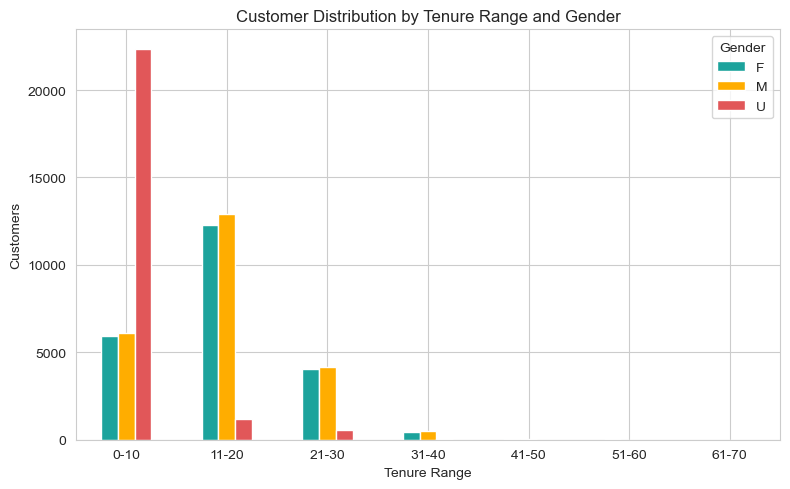

In [36]:
gendr_percentage = (demo["gendr"].value_counts(normalize=True) * 100).round(2)
print(gendr_percentage)

bins = [0, 10, 20, 30, 40, 50, 60, 70]
labels = ["0-10", "11-20", "21-30", "31-40", "41-50", "51-60", "61-70"]
demo["year_range"] = pd.cut(demo["clnt_tenure_yr"], bins=bins, labels=labels, include_lowest=True)

g_loyalty = (
    demo.groupby(["year_range", "gendr"], observed=False)
    .size()
    .reset_index(name="customers")
)

pivot_loyalty = g_loyalty.pivot(index="year_range", columns="gendr", values="customers")
pivot_loyalty.plot(kind="bar", figsize=(8, 5), color=["#1ca39c", "#ffad00", "#e15759"])
plt.xlabel("Tenure Range")
plt.ylabel("Customers")
plt.title("Customer Distribution by Tenure Range and Gender")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

## 3. Check experiment and web data

Before merging, I checked how much overlap existed between the three sources.

In [37]:
print("Shape:", experiment.shape)
print("Duplicate client_ids in experiment:", experiment["client_id"].duplicated().sum())
print("Variation sizes:")
print(experiment["variation"].value_counts())

print("Web rows:", len(web))
print("Unique clients in web:", web["client_id"].nunique())
print("Unique visitors:", web["visitor_id"].nunique())
print("Unique visits:", web["visit_id"].nunique())
print("Process steps:")
print(web["process_step"].value_counts())

demo_ids = set(demo["client_id"])
exp_ids = set(experiment["client_id"])
web_ids = set(web["client_id"])

print(f"Clients in demo:       {len(demo_ids):,}")
print(f"Clients in experiment: {len(exp_ids):,}")
print(f"Clients in web:        {len(web_ids):,}")
print(f"In all three:          {len(demo_ids & exp_ids & web_ids):,}")

Shape: (70609, 2)
Duplicate client_ids in experiment: 0
Variation sizes:
variation
Test       26968
Control    23532
Name: count, dtype: int64
Web rows: 755405
Unique clients in web: 120157
Unique visitors: 130236
Unique visits: 158095
Process steps:
process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64
Clients in demo:       70,594
Clients in experiment: 70,609
Clients in web:        120,157
In all three:          70,594


## 4. Initial funnel overview

As a first check, I looked at how many unique clients reached each step of the process.

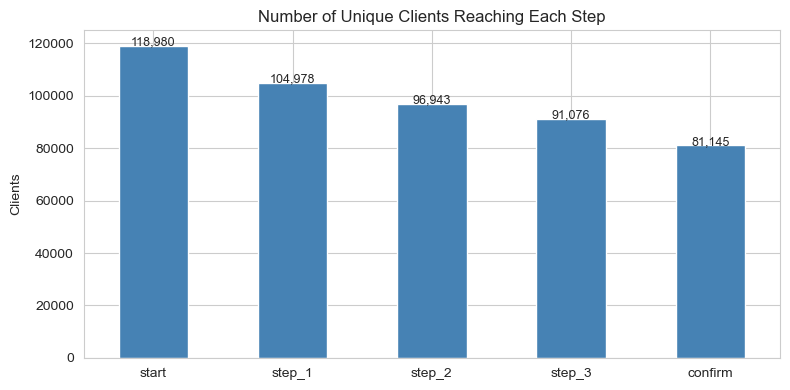

In [38]:
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
clients_per_step = (
    web.groupby("process_step")["client_id"]
    .nunique()
    .reindex(step_order)
)

fig, ax = plt.subplots(figsize=(8, 4))
clients_per_step.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Number of Unique Clients Reaching Each Step")
ax.set_ylabel("Clients")
ax.set_xlabel("")
ax.set_xticklabels(step_order, rotation=0)
for i, v in enumerate(clients_per_step.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Build a clean client-level base table

For the main A/B test result, I wanted one clear table at the client level.

In [39]:
merged = demo.merge(experiment, on="client_id", how="inner")
merged.columns = merged.columns.str.strip().str.lower().str.replace(" ", "_")

client_base = merged[
    [
        "client_id", "variation", "clnt_age", "age_group", "gendr",
        "num_accts", "bal", "calls_6_mnth", "logons_6_mnth",
        "clnt_tenure_yr", "clnt_tenure_mnth"
    ]
].drop_duplicates()

experiment_balance = client_base.groupby("variation").agg({
    "clnt_age": ["mean", "median"],
    "num_accts": ["mean"],
    "clnt_tenure_yr": ["mean"],
    "gendr": lambda x: x.value_counts().to_dict()
}).round(2)

experiment_balance

clnt_age        num_accts clnt_tenure_yr  \
              mean median      mean           mean   
variation                                            
Control      47.50   48.5      2.26          12.09   
Test         47.16   47.5      2.25          11.98   

                                       gendr  
                                    <lambda>  
variation                                     
Control    {'U': 8014, 'M': 7970, 'F': 7542}  
Test       {'U': 9268, 'M': 8977, 'F': 8716}

Because this is an A/B test, each client should belong to only one variation. I removed any clients that appeared in more than one group.

In [40]:
client_variation_check = client_base.groupby("client_id")["variation"].nunique()
valid_clients = client_variation_check[client_variation_check == 1].index

client_base = client_base[client_base["client_id"].isin(valid_clients)].copy()
web_clean = web[web["client_id"].isin(valid_clients)].copy()

print("Clients kept for A/B analysis:", client_base["client_id"].nunique())
print(client_base["variation"].value_counts())

Clients kept for A/B analysis: 50487
variation
Test       26961
Control    23526
Name: count, dtype: int64


## 6. Main A/B test question: completion rate

This is the most important section because Vanguard wants to know whether the new version improved completion and whether that improvement reaches the required **5% minimum lift**.

In [41]:
completion = (
    web_clean.groupby("client_id")
    .agg(completed=("process_step", lambda x: (x == "confirm").any()))
    .reset_index()
)

ab_result = client_base.merge(completion, on="client_id", how="left")
ab_result["completed"] = ab_result["completed"].fillna(False)

completion_summary = (
    ab_result.groupby("variation")
    .agg(
        clients=("client_id", "nunique"),
        completions=("completed", "sum"),
        completion_rate=("completed", "mean")
    )
    .reset_index()
)
completion_summary["completion_rate_pct"] = (completion_summary["completion_rate"] * 100).round(2)
completion_summary

,variation,clients,completions,completion_rate,completion_rate_pct
0,Control,23526,15428,0.655785,65.58
1,Test,26961,18682,0.692927,69.29


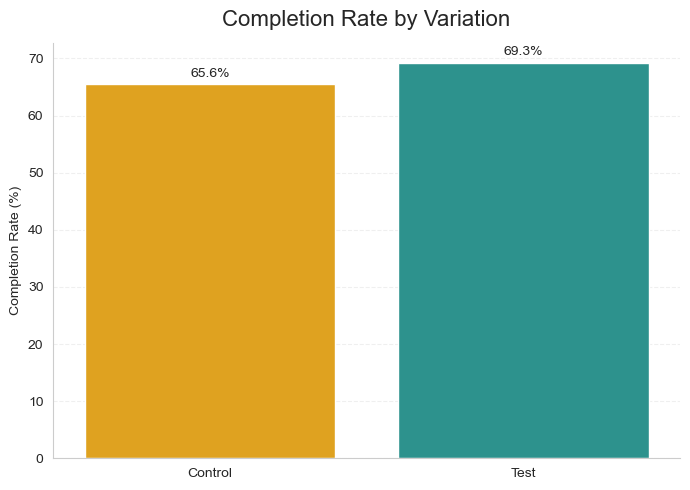

Control completion rate: 65.58%
Test completion rate: 69.29%
Absolute difference: 3.71%
Relative lift: 5.66%
Z-statistic: 8.8927
P-value: 0.000000


In [42]:
plt.figure(figsize=(7, 5), facecolor="white")
ax = sns.barplot(
    data=completion_summary,
    x="variation",
    y="completion_rate_pct",
    hue="variation",
    palette={"Control": "#ffad00", "Test": "#1ca39c"},
    dodge=False,
    legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
ax.set_title("Completion Rate by Variation", fontsize=16, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Completion Rate (%)")
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

control_rate = completion_summary.loc[completion_summary["variation"] == "Control", "completion_rate"].iloc[0]
test_rate = completion_summary.loc[completion_summary["variation"] == "Test", "completion_rate"].iloc[0]
absolute_diff = test_rate - control_rate
relative_lift = absolute_diff / control_rate

control_completed = ab_result.loc[ab_result["variation"] == "Control", "completed"].sum()
test_completed = ab_result.loc[ab_result["variation"] == "Test", "completed"].sum()
control_n = ab_result.loc[ab_result["variation"] == "Control", "client_id"].nunique()
test_n = ab_result.loc[ab_result["variation"] == "Test", "client_id"].nunique()

counts = np.array([test_completed, control_completed])
nobs = np.array([test_n, control_n])
z_stat, p_value = proportions_ztest(counts, nobs)

print(f"Control completion rate: {control_rate:.2%}")
print(f"Test completion rate: {test_rate:.2%}")
print(f"Absolute difference: {absolute_diff:.2%}")
print(f"Relative lift: {relative_lift:.2%}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

## 7. Navigation funnel comparison

Besides the final completion rate, I also wanted to compare how far clients progressed through the funnel in each variation.

In [43]:
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
step_reach = []
for variation in ["Control", "Test"]:
    temp = web_clean.merge(client_base[["client_id", "variation"]], on="client_id", how="inner")
    temp = temp[temp["variation"] == variation]
    total_clients = temp["client_id"].nunique()
    row = {"variation": variation, "start": 100.0}
    for step in ["step_1", "step_2", "step_3", "confirm"]:
        reached = temp.loc[temp["process_step"] == step, "client_id"].nunique()
        row[step] = reached / total_clients * 100
    step_reach.append(row)

pivot_funnel = pd.DataFrame(step_reach).set_index("variation").reindex(["Control", "Test"])
pivot_funnel = pivot_funnel[step_order].round(1)
pivot_funnel

,start,step_1,step_2,step_3,confirm
variation,,,,,
Control,100.0,85.6,79.2,74.0,65.6
Test,100.0,90.0,82.5,77.4,69.3


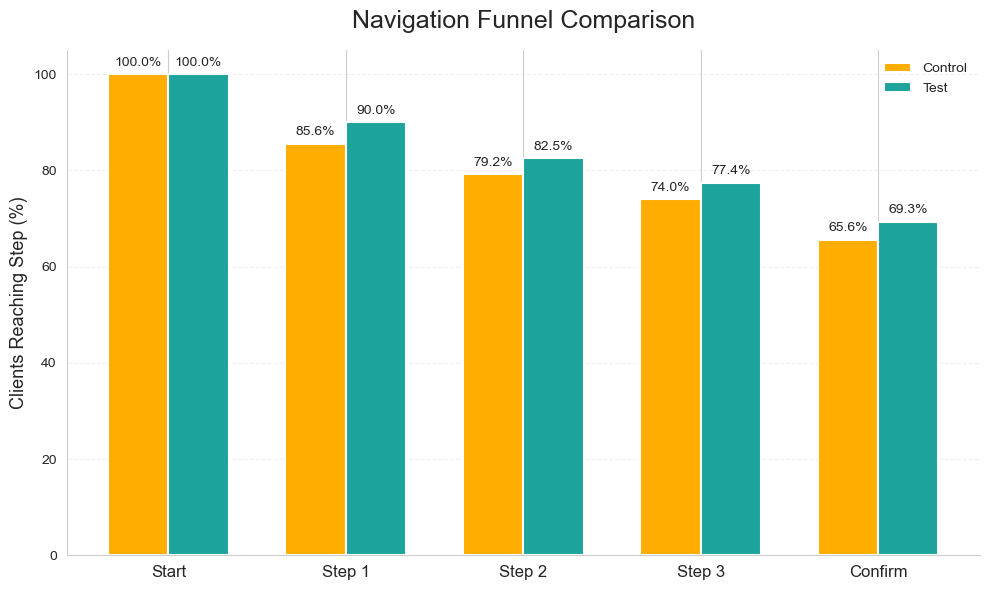

In [44]:
x = np.arange(len(step_order))
width = 0.34
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")

bars1 = ax.bar(x - width/2, pivot_funnel.loc["Control"], width, label="Control", color="#ffad00", edgecolor="white", linewidth=1.5)
bars2 = ax.bar(x + width/2, pivot_funnel.loc["Test"], width, label="Test", color="#1ca39c", edgecolor="white", linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}%", xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=10)

ax.set_title("Navigation Funnel Comparison", fontsize=18, pad=16)
ax.set_ylabel("Clients Reaching Step (%)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(["Start", "Step 1", "Step 2", "Step 3", "Confirm"], fontsize=12)
ax.set_ylim(0, 105)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 8. Build a journey table for error analysis

After the main A/B result, I looked more closely at user behavior inside the process. For this section, I removed clients with gaps longer than one hour between steps and treated them as interrupted journeys.

In [45]:
journey_df = web_clean.merge(
    client_base[["client_id", "variation", "age_group", "gendr", "num_accts", "calls_6_mnth", "logons_6_mnth"]],
    on="client_id",
    how="left"
)

journey_df = journey_df.sort_values(["client_id", "date_time"]).copy()
journey_df["next_time"] = journey_df.groupby("client_id")["date_time"].shift(-1)
journey_df["step_gap_sec"] = (journey_df["next_time"] - journey_df["date_time"]).dt.total_seconds()
clients_over_1h = journey_df.loc[journey_df["step_gap_sec"] > 3600, "client_id"].unique()
journey_df = journey_df[~journey_df["client_id"].isin(clients_over_1h)].copy()

print("Journey rows after removing >1h gaps:", len(journey_df))
print("Clients kept in journey table:", journey_df["client_id"].nunique())

Journey rows after removing >1h gaps: 203427
Clients kept in journey table: 38696


In [46]:
journey_df["step_full"] = journey_df["process_step"].fillna("start")
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
step_map = {step: i for i, step in enumerate(step_order)}

journey_df["step_num"] = journey_df["step_full"].map(step_map)
journey_df["next_step"] = journey_df.groupby("client_id")["step_full"].shift(-1)
journey_df["next_step_num"] = journey_df.groupby("client_id")["step_num"].shift(-1)
journey_df["step_diff"] = journey_df["next_step_num"] - journey_df["step_num"]

journey_df["is_error"] = np.where(
    journey_df["next_step_num"].isna(),
    np.nan,
    ~journey_df["step_diff"].isin([0, 1])
)

journey_df["error_type"] = "valid"
journey_df.loc[journey_df["step_diff"] < 0, "error_type"] = "backward"
journey_df.loc[journey_df["step_diff"] > 1, "error_type"] = "skip_forward"
journey_df.loc[journey_df["next_step_num"].isna(), "error_type"] = None

journey_df[["client_id", "step_full", "next_step", "step_diff", "is_error", "error_type"]].head(10)

,client_id,step_full,next_step,step_diff,is_error,error_type
70774,555,start,step_1,1.0,0.0,valid
70773,555,step_1,step_2,1.0,0.0,valid
70772,555,step_2,step_3,1.0,0.0,valid
70771,555,step_3,confirm,1.0,0.0,valid
70770,555,confirm,NaN,NaN,NaN,None
135876,647,start,step_1,1.0,0.0,valid
135875,647,step_1,step_2,1.0,0.0,valid
135874,647,step_2,step_3,1.0,0.0,valid
135873,647,step_3,confirm,1.0,0.0,valid
135870,647,confirm,NaN,NaN,NaN,None


## 9. Error rates by variation and age group

I first measured the overall transition-level error rate and then broke it down by age group.

In [47]:
error_rate = journey_df["is_error"].mean() * 100
print(f"Overall error rate: {error_rate:.2f}%")

error_by_variation = (
    journey_df.groupby("variation")["is_error"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="error_rate_pct")
)

error_by_age = (
    journey_df.groupby(["age_group", "variation"], observed=False)["is_error"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="error_rate_pct")
)

pivot_error_age = (
    error_by_age.pivot(index="age_group", columns="variation", values="error_rate_pct")
    .reindex(["18-34", "35-44", "45-54", "55-64", "65+"])
    .round(2)
)

error_by_variation, pivot_error_age

Overall error rate: 9.68%


(  variation  error_rate_pct
 0   Control            8.57
 1      Test           10.56,
 variation  Control   Test
 age_group                
 18-34         8.19   8.70
 35-44         7.69   9.42
 45-54         8.29  11.33
 55-64         9.24  12.27
 65+          10.05  12.50)

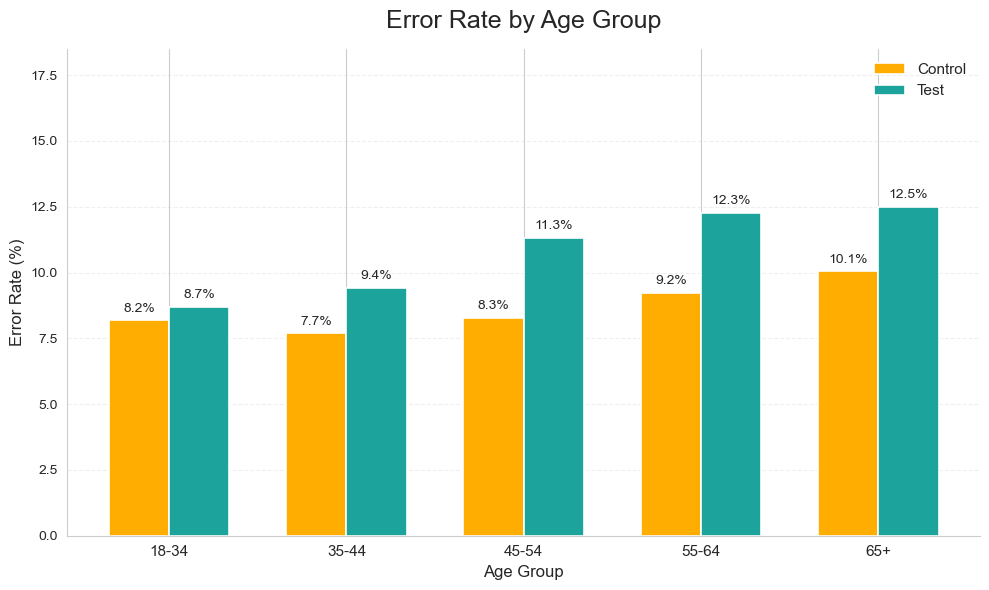

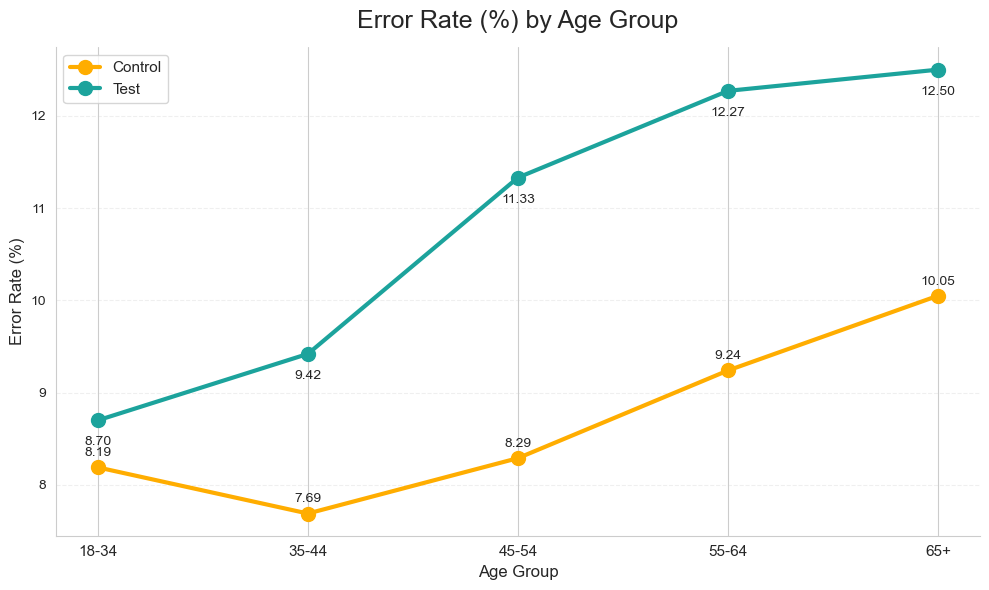

In [48]:
plot_df = pivot_error_age.reindex(["18-34", "35-44", "45-54", "55-64", "65+"])
x = np.arange(len(plot_df.index))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")
bars1 = ax.bar(x - width/2, plot_df["Control"], width, label="Control", color="#ffad00", edgecolor="white", linewidth=1.2)
bars2 = ax.bar(x + width/2, plot_df["Test"], width, label="Test", color="#1ca39c", edgecolor="white", linewidth=1.2)
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}%", xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=10)
ax.set_title("Error Rate by Age Group", fontsize=18, pad=15)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Error Rate (%)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, fontsize=11)
ax.set_ylim(0, max(plot_df.max()) + 6)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")
ax.plot(x, plot_df["Control"], marker="o", markersize=10, linewidth=3, label="Control", color="#ffad00")
ax.plot(x, plot_df["Test"], marker="o", markersize=10, linewidth=3, label="Test", color="#1ca39c")
for i, y in enumerate(plot_df["Control"]):
    ax.annotate(f"{y:.2f}", (x[i], y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=10)
for i, y in enumerate(plot_df["Test"]):
    ax.annotate(f"{y:.2f}", (x[i], y), textcoords="offset points", xytext=(0, -18), ha="center", fontsize=10)
ax.set_title("Error Rate (%) by Age Group", fontsize=18, pad=14)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Error Rate (%)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, fontsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

## 10. Backward errors and transition patterns

The overall error rate is helpful, but I also wanted to see where those errors happened most often.

In [49]:
errors_by_step = (
    journey_df[journey_df["is_error"] == True]
    .groupby(["variation", "step_full"])
    .size()
    .reset_index(name="error_count")
)

pivot_step = errors_by_step.pivot(index="step_full", columns="variation", values="error_count").fillna(0)
pivot_step_pct = pivot_step.div(pivot_step.sum(axis=0), axis=1) * 100
pivot_step_pct = pivot_step_pct.loc[pivot_step_pct.sum(axis=1).sort_values().index]
pivot_step_pct

variation,Control,Test
step_full,,
start,2.978383,3.980202
confirm,7.878303,1.948855
step_2,21.345076,27.253042
step_1,22.001601,40.162920
step_3,45.796637,26.654980


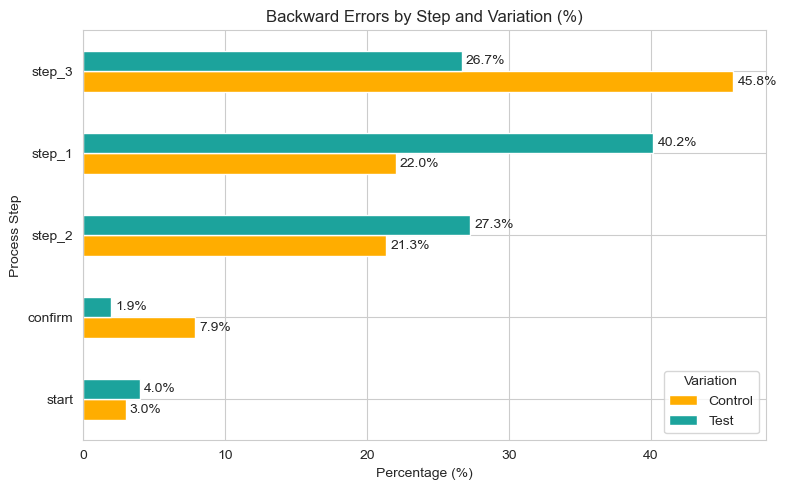

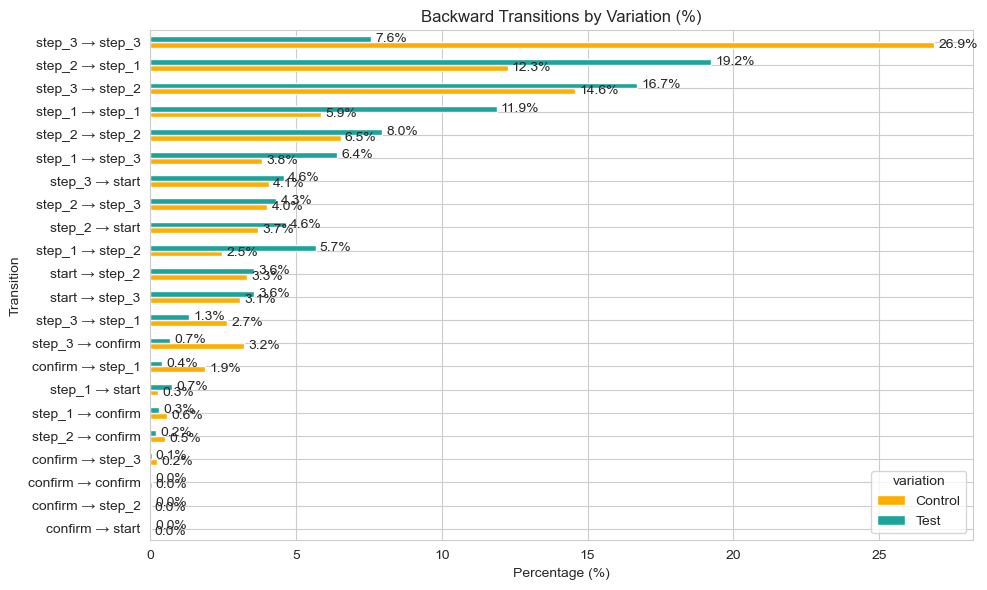

In [50]:
ax = pivot_step_pct.plot(kind="barh", figsize=(8, 5), color=["#ffad00", "#1ca39c"])
plt.title("Backward Errors by Step and Variation (%)")
plt.xlabel("Percentage (%)")
plt.ylabel("Process Step")
plt.legend(title="Variation")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

backward_flows = journey_df[journey_df["is_error"] == True].copy()
backward_flows["prev_step_name"] = backward_flows.groupby(["variation", "client_id"])["step_full"].shift(1)
backward_flows = (
    backward_flows.groupby(["variation", "prev_step_name", "step_full"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
backward_flows["transition"] = backward_flows["prev_step_name"] + " → " + backward_flows["step_full"]

pivot_flows = backward_flows.pivot_table(index="transition", columns="variation", values="count", fill_value=0)
pivot_flows = pivot_flows.div(pivot_flows.sum(axis=0), axis=1) * 100
pivot_flows = pivot_flows.loc[pivot_flows.sum(axis=1).sort_values().index]

ax = pivot_flows.plot(kind="barh", figsize=(10, 6), color=["#ffad00", "#1ca39c"])
plt.title("Backward Transitions by Variation (%)")
plt.xlabel("Percentage (%)")
plt.ylabel("Transition")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

## 11. Time spent in the process

Another way to compare Control and Test is to look at average time spent in each step.

In [56]:
time_df = journey_df.sort_values(["client_id", "date_time"]).copy()
time_df["next_time"] = time_df.groupby("client_id")["date_time"].shift(-1)
time_df["time_spent_sec"] = (time_df["next_time"] - time_df["date_time"]).dt.total_seconds()
time_df = time_df[(time_df["time_spent_sec"] > 0) & (time_df["time_spent_sec"] < 1800)].copy()

time_per_step = (
    time_df.groupby(["variation", "process_step"])["time_spent_sec"]
    .mean()
    .reset_index()
    .round(2)
)

pivot_time = time_per_step.pivot(index="process_step", columns="variation", values="time_spent_sec")
pivot_time = pivot_time.reindex(["start", "step_1", "step_2", "step_3", "confirm"])
pivot_time

variation,Control,Test
process_step,,
start,56.29,49.92
step_1,44.60,56.76
step_2,90.76,89.56
step_3,128.91,113.35
confirm,154.97,212.42


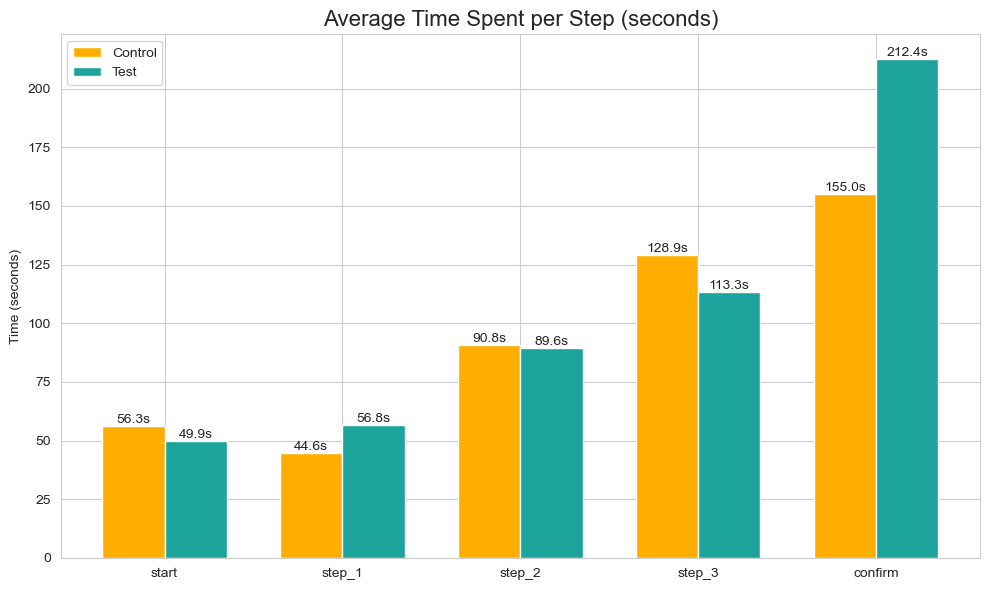

In [52]:
x = np.arange(len(pivot_time.index))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, pivot_time["Control"], width, label="Control", color="#ffad00")
bars2 = ax.bar(x + width/2, pivot_time["Test"], width, label="Test", color="#1ca39c")
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f"{h:.1f}s", ha="center", va="bottom", fontsize=10)
ax.set_title("Average Time Spent per Step (seconds)", fontsize=16)
ax.set_ylabel("Time (seconds)")
ax.set_xticks(x)
ax.set_xticklabels(pivot_time.index)
ax.legend()
plt.tight_layout()
plt.show()

## 12. Calls and logins by age group

After looking at behavior inside the funnel, I also wanted to compare broader client usage patterns.

In [57]:
merged_calls = journey_df.copy()
client_level = merged_calls[["client_id", "age_group", "gendr", "variation", "calls_6_mnth", "logons_6_mnth"]].drop_duplicates()
client_level = client_level[
    client_level["gendr"].notna() &
    (client_level["gendr"] != "U") &
    (client_level["age_group"] != "0-17")
].copy()

age_summary = (
    client_level.groupby(["age_group", "variation"], observed=False)[["calls_6_mnth", "logons_6_mnth"]]
    .mean()
    .reset_index()
    .round(2)
)

age_order = ["18-34", "35-44", "45-54", "55-64", "65+"]
age_summary["age_group"] = pd.Categorical(age_summary["age_group"], categories=age_order, ordered=True)
age_summary.head()

,age_group,variation,calls_6_mnth,logons_6_mnth
0,18-34,Control,3.06,6.09
1,18-34,Test,2.89,5.91
2,35-44,Control,2.67,5.69
3,35-44,Test,2.69,5.72
4,45-54,Control,2.78,5.82


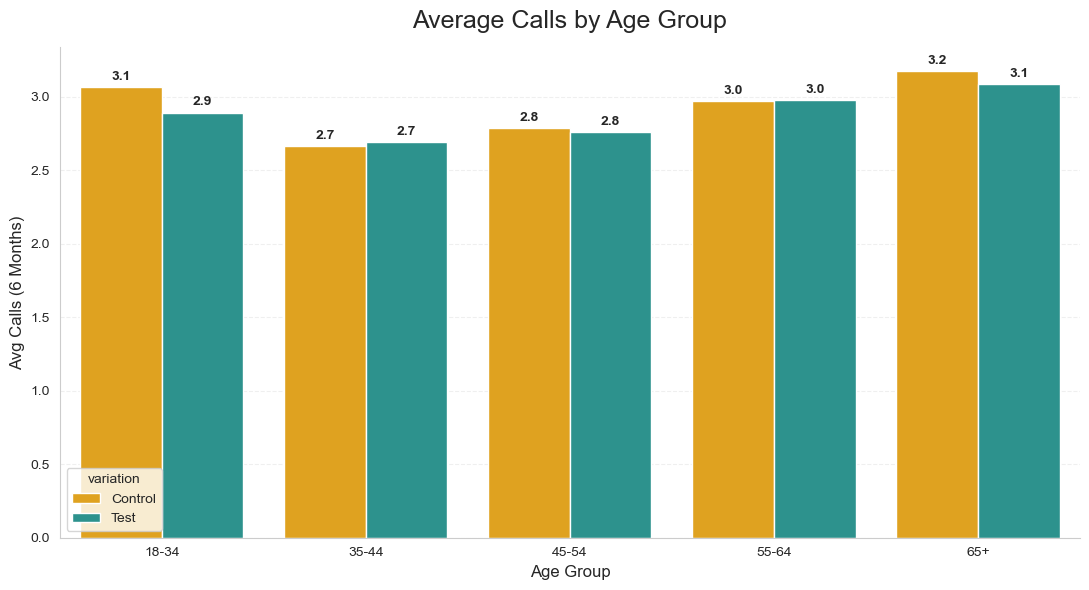

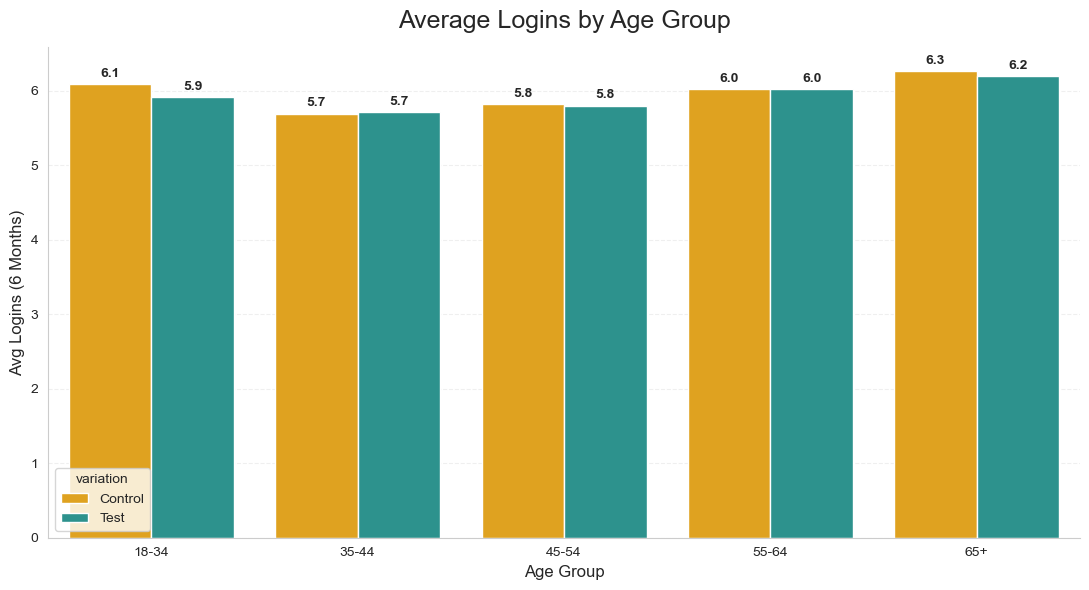

In [54]:
def add_labels(ax):
    for container in ax.containers:
        labels = [f"{v:.1f}" for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=10, fontweight="bold")

palette = {"Control": "#ffad00", "Test": "#1ca39c"}

plt.figure(figsize=(11, 6), facecolor="white")
ax = sns.barplot(data=age_summary, x="age_group", y="calls_6_mnth", hue="variation", palette=palette)
add_labels(ax)
ax.set_title("Average Calls by Age Group", fontsize=18, pad=14)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Avg Calls (6 Months)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6), facecolor="white")
ax = sns.barplot(data=age_summary, x="age_group", y="logons_6_mnth", hue="variation", palette=palette)
add_labels(ax)
ax.set_title("Average Logins by Age Group", fontsize=18, pad=14)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Avg Logins (6 Months)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

## 13. Error rate by age group and number of accounts

Finally, I explored whether the number of accounts held by a client seemed related to the probability of making errors.

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_92877/3835136627.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .agg(had_error=("is_error", lambda x: x.fillna(False).any()))
/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_92877/3835136627.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  segment_df["had_error"] = segment_df["had_error"].fillna(False)
/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_92877/3835136627.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=Tr

===== Control: Error Rate (%) =====
num_accts   2.0   3.0   4.0   5.0   6.0  7.0
age_group                                   
18-34      20.1  16.9  18.8  13.6   0.0  NaN
35-44      16.6  17.3  20.5   9.5   0.0  NaN
45-54      18.4  12.9  14.8  10.7  50.0  0.0
55-64      17.6  17.5  11.0   0.0   0.0  0.0
65+        15.9  15.6  16.3   5.3   0.0  NaN
===== Test: Error Rate (%) =====
num_accts  1.0   2.0   3.0   4.0   5.0   6.0   7.0
age_group                                         
18-34      0.0  22.5  18.6  14.8  16.7   0.0   0.0
35-44      NaN  22.5  19.3  18.9   5.3   NaN  50.0
45-54      NaN  24.5  18.4   9.7  24.0   0.0   NaN
55-64      NaN  23.4  20.1  17.1  13.6  20.0   0.0
65+        NaN  21.2  18.7  12.6  15.4  25.0   NaN


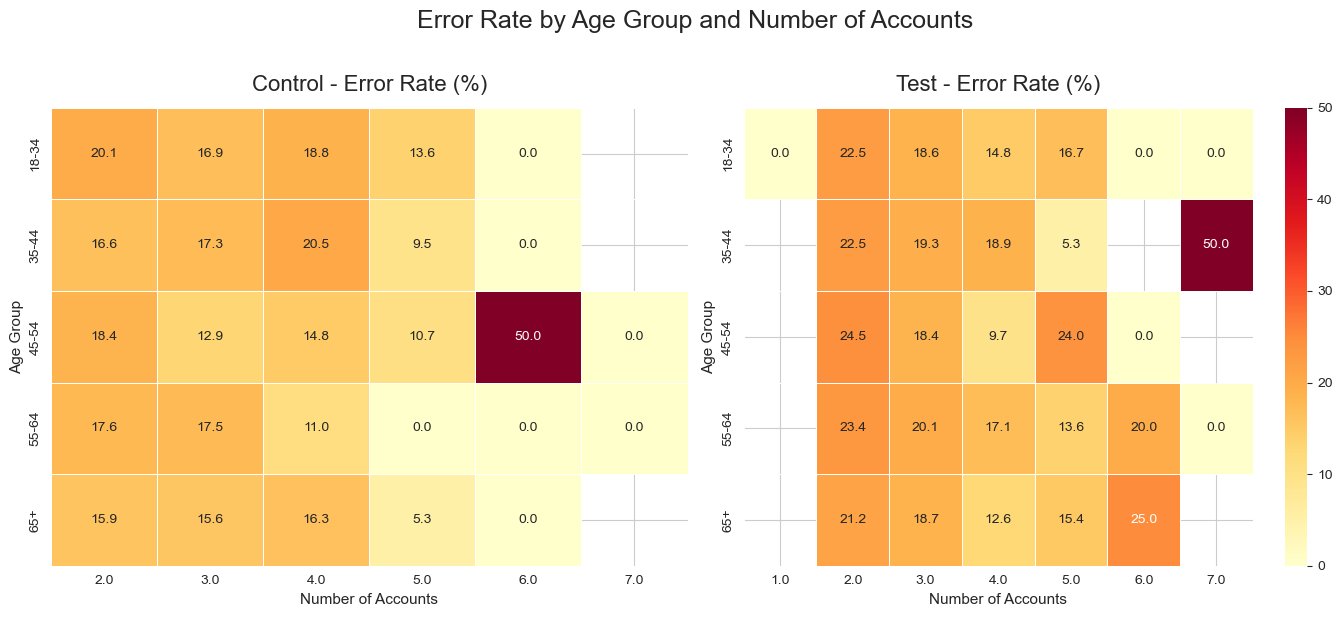

In [59]:
client_error = (
    journey_df.groupby("client_id")
    .agg(had_error=("is_error", lambda x: x.fillna(False).any()))
    .reset_index()
)

segment_df = client_base.merge(client_error, on="client_id", how="left")
segment_df["had_error"] = segment_df["had_error"].fillna(False)
segment_df = segment_df[segment_df["age_group"] != "0-17"].copy()

for var in ["Control", "Test"]:
    temp = segment_df[segment_df["variation"] == var]
    pivot = pd.pivot_table(temp, index="age_group", columns="num_accts", values="had_error", aggfunc="mean") * 100
    print(f"===== {var}: Error Rate (%) =====")
    print(pivot.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="white")
for ax, var in zip(axes, ["Control", "Test"]):
    temp = segment_df[segment_df["variation"] == var]
    pivot = pd.pivot_table(temp, index="age_group", columns="num_accts", values="had_error", aggfunc="mean") * 100
    pivot = pivot.round(1)
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, cbar=ax == axes[1], ax=ax)
    ax.set_title(f"{var} - Error Rate (%)", fontsize=16, pad=12)
    ax.set_xlabel("Number of Accounts", fontsize=11)
    ax.set_ylabel("Age Group", fontsize=11)
plt.suptitle("Error Rate by Age Group and Number of Accounts", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [60]:
print("FINAL RECOMMENDATION")
print("-------------------")
print(f"Control completion rate: {control_rate:.2%}")
print(f"Test completion rate: {test_rate:.2%}")
print(f"Relative lift: {relative_lift:.2%}")
print(f"P-value: {p_value:.6f}")

if (relative_lift >= 0.05) and (p_value < 0.05):
    print("The new design clears both the statistical and business thresholds.")
elif (relative_lift < 0.05) and (p_value < 0.05):
    print("The result is statistically significant, but it does not reach Vanguard's 5% business threshold.")
else:
    print("The redesign does not provide enough evidence for rollout.")

FINAL RECOMMENDATION
-------------------
Control completion rate: 65.58%
Test completion rate: 69.29%
Relative lift: 5.66%
P-value: 0.000000
The new design clears both the statistical and business thresholds.
